In [27]:
#Loading necessary libraries for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
%matplotlib inline
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy import stats
import seaborn as sns
!pip install yfinance
!pip show yfinance
import yfinance as yf
np.set_printoptions(legacy='1.25')

Name: yfinance
Version: 0.2.54
Summary: Download market data from Yahoo! Finance API
Home-page: https://github.com/ranaroussi/yfinance
Author: Ran Aroussi
Author-email: ran@aroussi.com
License: Apache
Location: /usr/local/lib/python3.11/dist-packages
Requires: beautifulsoup4, frozendict, multitasking, numpy, pandas, peewee, platformdirs, pytz, requests
Required-by: 


In [28]:
stock = 'amzn'
YEARS = 10

In [29]:
data = yf.download(f"{stock}", start="1910-01-01", end="2050-01-02")
print(data.head())
#create average day price
data['avg_price'] = (data['Open'] + data['Close']) / 2
data.head()

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open      Volume
Ticker          AMZN      AMZN      AMZN      AMZN        AMZN
Date                                                          
1997-05-15  0.097917  0.125000  0.096354  0.121875  1443120000
1997-05-16  0.086458  0.098958  0.085417  0.098438   294000000
1997-05-19  0.085417  0.088542  0.081250  0.088021   122136000
1997-05-20  0.081771  0.087500  0.081771  0.086458   109344000
1997-05-21  0.071354  0.082292  0.068750  0.081771   377064000


Price,Close,High,Low,Open,Volume,avg_price
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,
Date,,,,,,
1997-05-15,0.097917,0.125000,0.096354,0.121875,1443120000,0.109896
1997-05-16,0.086458,0.098958,0.085417,0.098438,294000000,0.092448
1997-05-19,0.085417,0.088542,0.081250,0.088021,122136000,0.086719
1997-05-20,0.081771,0.087500,0.081771,0.086458,109344000,0.084114
1997-05-21,0.071354,0.082292,0.068750,0.081771,377064000,0.076563


In [30]:
# Create an instance of the Ticker class:
ticker = yf.Ticker(f"{stock}")
# Then, access the 'info' attribute:
ticker_info = ticker.info

# Check if the 'symbol' key exists before accessing it:
if 'symbol' in ticker_info:
    name = ticker_info['symbol']
else:
    # Handle the case where 'symbol' key is not found
    # For example, you can print a message or assign a default value to 'name'
    print(f"Warning: 'symbol' key not found in ticker_info for {stock}")
    name = stock  # Assign the original stock value as a fallback

print(ticker_info)
print(name)


{'address1': '410 Terry Avenue North', 'city': 'Seattle', 'state': 'WA', 'zip': '98109-5210', 'country': 'United States', 'phone': '206 266 1000', 'website': 'https://www.aboutamazon.com', 'industry': 'Internet Retail', 'industryKey': 'internet-retail', 'industryDisp': 'Internet Retail', 'sector': 'Consumer Cyclical', 'sectorKey': 'consumer-cyclical', 'sectorDisp': 'Consumer Cyclical', 'longBusinessSummary': "Amazon.com, Inc. engages in the retail sale of consumer products, advertising, and subscriptions service through online and physical stores in North America and internationally. The company operates through three segments: North America, International, and Amazon Web Services (AWS). It also manufactures and sells electronic devices, including Kindle, fire tablets, fire TVs, echo, ring, blink, and eero; and develops and produces media content. In addition, the company offers programs that enable sellers to sell their products in its stores; and programs that allow authors, independ

In [31]:
data = pd.DataFrame(data)
data['date'] = data.index
data.head()

Price,Close,High,Low,Open,Volume,avg_price,date
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,,
Date,,,,,,,
1997-05-15,0.097917,0.125000,0.096354,0.121875,1443120000,0.109896,1997-05-15
1997-05-16,0.086458,0.098958,0.085417,0.098438,294000000,0.092448,1997-05-16
1997-05-19,0.085417,0.088542,0.081250,0.088021,122136000,0.086719,1997-05-19
1997-05-20,0.081771,0.087500,0.081771,0.086458,109344000,0.084114,1997-05-20
1997-05-21,0.071354,0.082292,0.068750,0.081771,377064000,0.076563,1997-05-21


In [32]:
#Define CAGR function
def cagr(end, start, n):
    return (end/start)**(1/n)-1

In [33]:
#Convert date variable in the dataframe to a datetime variable
data['date'] = pd.to_datetime(data['date'])

In [34]:
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

In [35]:
#Compute CAGR of defined number of years.
results = []
for i in range(len(data)):
  start_date = data.iloc[[i],[6]]
  end_date = start_date.iloc[0, 0] + pd.DateOffset(years = YEARS)
  end_date = pd.DataFrame([end_date])
  try:
    data[data['date'] == end_date.iloc[0,0]].avg_price[0]
    results.append(cagr(data[data['date'] == end_date.iloc[0,0]].avg_price[0], data[data['date'] == start_date.iloc[0,0]].avg_price[0], YEARS))
  except:
    results.append('False')

<ipython-input-35-77c879ab111d>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data[data['date'] == end_date.iloc[0,0]].avg_price[0]
<ipython-input-35-77c879ab111d>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.append(cagr(data[data['date'] == end_date.iloc[0,0]].avg_price[0], data[data['date'] == start_date.iloc[0,0]].avg_price[0], YEARS))


In [36]:
results = pd.DataFrame(results)
results = results.rename(columns={0: 'CAGR'})
results = results[results['CAGR'] != 'False']
results = results['CAGR'].astype(float)

In [37]:
#User defined function for batch univariate data analysis of quantitative features in a dataset
def univariate_analysis(data, feature, include_def = True):
  """
  This function computes major and minor outliers
  as defined in 'Introduction to Contemporary Statistical Methods --  second edition' by Dr. Lambert H. Koopmans (pg. 53).
  Minor outliers are defined by those values which are beyond Q3/Q1 +/- 1.5*IQR but less than Q3/Q1 +/- 3*IQR
  Major/Extreme outliers are defined by those values which are beyond Q3/Q1 +/- 3*IQR
  Also, this function computes other relevant statistics and plots germane to a univariate analysis of a random variable.

  Please note the following definitions/descriptions of skewness and kurtosis from the Engineering Statistics Handbook (https://www.itl.nist.gov/div898/handbook/eda/section3/eda35b.htm):
  *Skewness is a measure of symmetry, or more precisely, the lack of symmetry. A distribution, or data set, is symmetric if it looks the same to the left and right of the center point.
  **Kurtosis is a measure of whether the data are heavy-tailed or light-tailed relative to a normal distribution. That is, data sets with high kurtosis tend to have heavy tails, or outliers.
  **Data sets with low kurtosis tend to have light tails, or lack of outliers. A uniform distribution would be the extreme case.
  """
  ##Display Plots
  fig, axes = plt.subplots(ncols = 3, figsize = (15,5))
  sns.boxplot(data = data, x = feature, ax = axes[0]).set(title = f'Boxplot of [{name}] {YEARS}-year {feature}')
  sns.histplot(data = data, x = feature, ax = axes[1]).set(title = f'Histogram plot of [{name}] {YEARS}-year {feature}')
  sns.kdeplot(data = data, x = feature, ax = axes[2]).set(title = f'Density plot of [{name}] {YEARS}-year {feature}')
  plt.show()

  Q1 = data[feature].quantile(.25) ; Q3 = data[feature].quantile(.75) ; Q2 = data[feature].quantile(.5) ; Mean = data[feature].mean()
  STD = np.std(data[feature]); SNR = Mean/STD ; CV = STD/Mean ; Skew = skew(data[feature], nan_policy = 'omit') ; Kurtosis = kurtosis(data[feature], nan_policy = 'omit')
  IQR = Q3 - Q1
  upper_fence = Q3 + 1.5*IQR ; lower_fence = Q1 - 1.5*IQR
  outer_upper_fence = Q3 + 3*IQR ; outer_lower_fence = Q1 - 3*IQR
  minor_outliers_Q3 = []
  major_outliers_Q3 = []
  minor_outliers_Q1 = []
  major_outliers_Q1 = []
  for i in range(data[(data[feature]>upper_fence) & (data[feature]<=outer_upper_fence)].shape[0]):
    minor_outliers_Q3.append(data[(data[feature]>upper_fence) & (data[feature]<=outer_upper_fence)].loc[:,feature].values[i])
  if len(minor_outliers_Q3) == 0:
    print('*There are no minor outliers beyond Quartile[3] + 1.5*IQR!')
  else:
    print('*The percentage of minor outliers beyond Quartile[3] + 1.5*IQR are:', str(round(len(minor_outliers_Q3) / results.shape[0], ndigits = 5)) + '%', 'and the average of these outliers are:', round(pd.Series(minor_outliers_Q3).mean(), ndigits=2))
  for i in range(data[data[feature]> outer_upper_fence].shape[0]):
    major_outliers_Q3.append(data[data[feature]> outer_upper_fence].loc[:,feature].values[i])
  if len(major_outliers_Q3) == 0:
    print('*There are no major outliers beyond Quartile[3] + 3*IQR!')
  else:
    print('*The percentage of major outliers beyond Quartile[3] + 3*IQR are:', str(round(len(major_outliers_Q3)/ results.shape[0], ndigits = 5)) + '%', 'and the average of these outliers are:', round(pd.Series(major_outliers_Q3).mean(), ndigits=2))
  for i in range(data[(data[feature]>= outer_lower_fence) & (data[feature]<lower_fence)].shape[0]):
    minor_outliers_Q1.append(data[(data[feature]>= outer_lower_fence) & (data[feature]<lower_fence)].loc[:,feature].values[i])
  if len(minor_outliers_Q1) == 0:
    print('*There are no minor outliers below Quartile[1] - 1.5*IQR!')
  else:
    print('*The percentage of minor outliers below Quartile[1] - 1.5*IQR are:', str(round(len(minor_outliers_Q1)/ results.shape[0], ndigits = 5)) + '%', 'and the average of these outliers are:', round(pd.Series(minor_outliers_Q1).mean(), ndigits=2))
  for i in range(data[(data[feature]<outer_lower_fence)].shape[0]):
    major_outliers_Q1.append(data[(data[feature]<outer_lower_fence)].loc[:,feature].values[i])
  if len(major_outliers_Q1) == 0:
    print('*There are no major outliers below Quartile[1] - 3*IQR!')
  else:
    print('*The percentage of major outliers below Quartile[1] - 3*IQR are:', str(round(len(major_outliers_Q1)/ results.shape[0], ndigits = 5)) + '%', 'and the average of these outliers are:', round(pd.Series(major_outliers_Q1).mean(), ndigits=2))
  print('-'*50)
  print('-'*50)
  print('*Quartile[1] is:', round(Q1, ndigits=2))
  print('*Quartile[2] (median) is:', round(Q2, ndigits = 2))
  print('*Quartile[3] is:', round(Q3, ndigits = 2))
  print('*Quartile[1] - 1.5*IQR = ', round(lower_fence, ndigits = 2))
  print('*Quartile[1] - 3*IQR = ', round(outer_lower_fence, ndigits=2))
  print('*Quartile[3] + 1.5*IQR = ', round(upper_fence, ndigits=2))
  print('*Quartile[3] + 3*IQR = ', round(outer_upper_fence, ndigits=2))
  print('-'*50)
  print('-'*50)
  res = stats.ttest_1samp(results['CAGR'], popmean = 0)
  ci = res.confidence_interval(confidence_level = 0.95)

  print(f'*Average (point estimate) of {feature} is:', [round(Mean, ndigits=3)])
  print(f'*Standard deviation of {feature} is:', round(STD, ndigits=2))
  print(f'*Skewness of {feature} is:', round(Skew, ndigits=2))
  print(f'*Kurtosis of {feature} is:', round(Kurtosis, ndigits = 2))
  print(f'*Coefficient of variation of {feature} is:', round(abs(CV), ndigits = 2))
  if results[results['CAGR'] < 0].shape[0] > 0:
    print('*The probability of capital loss = ' + str(round(100 * (results[results['CAGR'] < 0].shape[0] / results.shape[0]), ndigits = 3)) + '%'+ ' for an average loss of '+ str(round(np.mean(results[results['CAGR']<=0]), ndigits = 3)) )
  else:
    print('*By the rule of three: the 95% upper bound estimate on probability of capital loss = ' + str(round(100*(3/results.shape[0]), ndigits = 3)) + '%')

  print('-'*50)
  print('*Number of data points:' +  str(results.shape[0]))
  print('-'*50)
  print(f'*Range of {feature} is:', [round(data[feature].min(), ndigits = 2), round(data[feature].max(), ndigits = 2)])
  print('-'*50)




  if data[feature].min()>=0:
    print(f'*Signal to Noise Ratio of {feature} is:', round(SNR, ndigits=2))
    print('**Note: Signal to Noise Ratio statistic is only applicable to variables which are always non-negative**')
  else:
    print('*Signal to Noise Ratio DOES NOT EXIST')
  print('-'*50)
  print('-'*50)

  if include_def == True:
    print('**Definitions:')
    print(f'*Skewness is a measure of symmetry, or more precisely, the lack of symmetry. \n A distribution, or data set, is symmetric if it looks the same to the left and right of the center point.')

    print(f'*Kurtosis is a measure of whether the data are heavy-tailed or light-tailed relative to a normal distribution. \n That is: data sets with high kurtosis tend to have heavy tails, or outliers. \n Data sets with low kurtosis tend to have light tails, or lack of outliers. A uniform distribution would be the extreme case.')








In [38]:
results = pd.DataFrame(results)

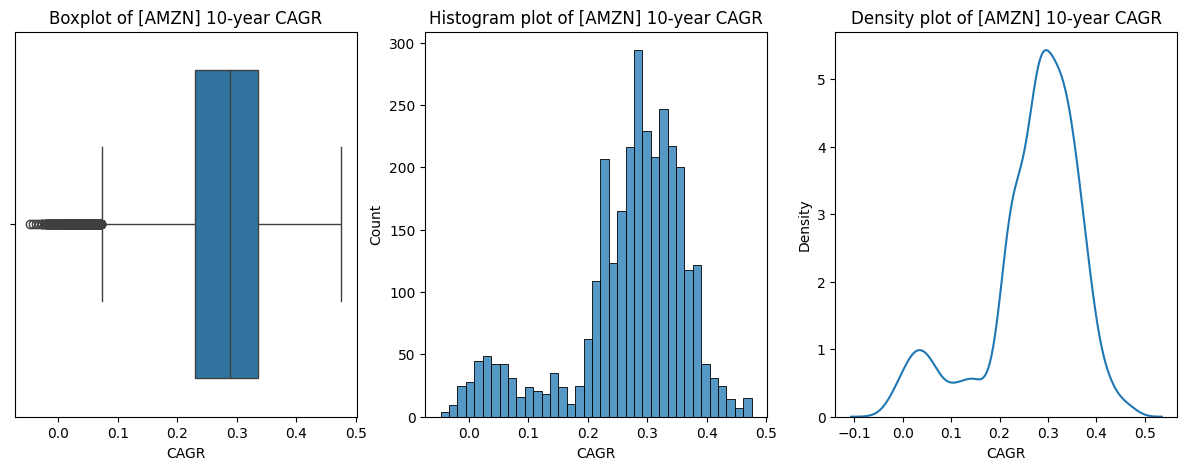

*There are no minor outliers beyond Quartile[3] + 1.5*IQR!
*There are no major outliers beyond Quartile[3] + 3*IQR!
*The percentage of minor outliers below Quartile[1] - 1.5*IQR are: 0.08551% and the average of these outliers are: 0.03
*There are no major outliers below Quartile[1] - 3*IQR!
--------------------------------------------------
--------------------------------------------------
*Quartile[1] is: 0.23
*Quartile[2] (median) is: 0.29
*Quartile[3] is: 0.34
*Quartile[1] - 1.5*IQR =  0.07
*Quartile[1] - 3*IQR =  -0.09
*Quartile[3] + 1.5*IQR =  0.49
*Quartile[3] + 3*IQR =  0.65
--------------------------------------------------
--------------------------------------------------
*Average (point estimate) of CAGR is: [0.27]
*Standard deviation of CAGR is: 0.1
*Skewness of CAGR is: -1.13
*Kurtosis of CAGR is: 1.03
*Coefficient of variation of CAGR is: 0.37
*The probability of capital loss = 1.484% for an average loss of -0.015
--------------------------------------------------
*Numbe

In [39]:
univariate_analysis(results, 'CAGR')